# Bank Customer Churn Prediction

Predicting which bank customers are likely to churn using classification algorithms.

**Problem:** Given customer demographic and account information, predict whether
a customer will exit or stay with the bank.

**Approach:**

1.Load and check the data

2.Encode categorical features and scale numeric ones

3.Train and compare 5 classification algorithms

4.Evaluate with confusion matrix, precision/recall/F1

5.Inspect which features drive churn the most

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

**1. Load the data**

In [8]:
dataset=pd.read_csv("Bank_Churn_Synthetic_Dataset.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15600000,Roberts,550,Germany,Female,47,4,50413.16,2,0,1,73307.05,0
1,2,15600001,Smith,506,France,Male,54,8,27927.87,2,1,0,163195.29,0
2,3,15600002,Clarke,780,Germany,Female,57,0,8487.83,1,1,1,27198.35,0
3,4,15600003,Baker,850,Spain,Female,41,7,106885.20,2,0,0,127951.09,0
4,5,15600004,Martin,604,France,Male,45,2,0.00,3,1,1,197523.65,0


In [ ]:
dataset.info()

## 2. Prepare features

- Drop identifier columns that carry no predictive signal (`RowNumber`, `CustomerId`, `Surname`)
- Keep `CustomerId` aside so we can still trace predictions back to a customer
- one-hot encode `Geography` and `Gender` which are categorical
- Everything else is numeric and gets scaled

In [5]:
x =dataset.iloc[:, 3:-1].values
y =dataset.iloc[:,13].values
customer_ids = dataset["CustomerId"].values
print(x[0])

[677 'France' 'Male' 65 4 61222.96 2 0 0 122193.58]


In [6]:
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder
ohe= ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[1,2])],remainder='passthrough')
x=np.array(ohe.fit_transform(x))

## 3. Train/test split and scaling

In [40]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test, id_train, id_test = train_test_split(x, y, customer_ids, test_size=0.2, random_state=0)

In [41]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test) 

## 4. Train and compare multiple models

Instead of only trying one algorithm, we train five classic classifiers on the
same train/test split so we can fairly compare them.

In [42]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(max_iter=1000)
classifier.fit(x_train, y_train)
y_pred=classifier.predict(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
logistic_accuracy=accuracy_score(y_test, y_pred)
logistic_precision=precision_score(y_test, y_pred)
logistic_recall=recall_score(y_test, y_pred)
logistic_f1=f1_score(y_test, y_pred)

In [43]:
from sklearn.neighbors import KNeighborsClassifier
classifier=KNeighborsClassifier(n_neighbors=5)
classifier.fit(x_train, y_train)
y_pred=classifier.predict(x_test)

knn_accuracy=accuracy_score(y_test, y_pred)
knn_precision=precision_score(y_test, y_pred)
knn_recall=recall_score(y_test, y_pred)
knn_f1=f1_score(y_test, y_pred)

In [44]:
from sklearn.svm import SVC
classifier=SVC(kernel="linear", random_state=0)
classifier.fit(x_train, y_train)
y_pred=classifier.predict(x_test)

svm_accuracy=accuracy_score(y_test, y_pred)
svm_precision=precision_score(y_test, y_pred)
svm_recall=recall_score(y_test, y_pred)
svm_f1=f1_score(y_test, y_pred)

In [45]:
from sklearn.tree import DecisionTreeClassifier
classifier=DecisionTreeClassifier(random_state=0)
classifier.fit(x_train, y_train)
y_pred=classifier.predict(x_test)

tree_accuracy=accuracy_score(y_test, y_pred)
tree_precision=precision_score(y_test, y_pred)
tree_recall=recall_score(y_test, y_pred)
tree_f1=f1_score(y_test, y_pred)

In [46]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=500, random_state=0)
classifier.fit(x_train, y_train)
y_pred=classifier.predict(x_test)

forest_accuracy=accuracy_score(y_test, y_pred)
forest_precision=precision_score(y_test, y_pred)
forest_recall=recall_score(y_test, y_pred)
forest_f1=f1_score(y_test, y_pred)

In [47]:
results_df=pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM (linear)",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[logistic_accuracy,knn_accuracy,svm_accuracy,tree_accuracy,forest_accuracy],
    "Precision (churn)":[logistic_precision,knn_precision,svm_precision,tree_precision,forest_precision],
    "Recall (churn)": [logistic_recall,knn_recall,svm_recall,tree_recall,forest_recall],  
    "F1 (churn)": [logistic_f1,knn_f1,svm_f1,tree_f1,forest_f1]
})
results_df=results_df.sort_values("F1 (churn)", ascending=False)
results_df

,Model,Accuracy,Precision (churn),Recall (churn),F1 (churn)
4,Random Forest,0.710,0.671875,0.5375,0.597222
2,SVM (linear),0.690,0.645161,0.5000,0.563380
0,Logistic Regression,0.695,0.666667,0.4750,0.554745
3,Decision Tree,0.605,0.505747,0.5500,0.526946
1,KNN,0.630,0.544118,0.4625,0.500000


In [48]:
# find the best model
best_model_name=results_df.iloc[0]["Model"]
if best_model_name=="Logistic Regression":
    best_model=LogisticRegression(max_iter=1000)
elif best_model_name=="KNN":
    best_model=KNeighborsClassifier(n_neighbors=5)
elif best_model_name=="SVM (linear)":
    best_model=SVC(kernel="linear", random_state=0)
elif best_model_name=="Decision Tree":
    best_model=DecisionTreeClassifier(random_state=0)
elif best_model_name=="Random Forest":
    best_model=RandomForestClassifier(n_estimators=500, random_state=0)

best_model.fit(x_train, y_train)
y_pred_best=best_model.predict(x_test)

print("Best model by F1-score:", best_model_name)

Best model by F1-score: Random Forest


## 5. Evaluate the best model

In [49]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[99 21]
 [37 43]]
              precision    recall  f1-score   support

           0       0.73      0.82      0.77       120
           1       0.67      0.54      0.60        80

    accuracy                           0.71       200
   macro avg       0.70      0.68      0.69       200
weighted avg       0.71      0.71      0.70       200



## 6. Which features drive churn the most?

Random Forest gives us a feature importance score for free, which is useful
for explaining the model to a non-technical audience(less active
customers with more products are more likely to churn").

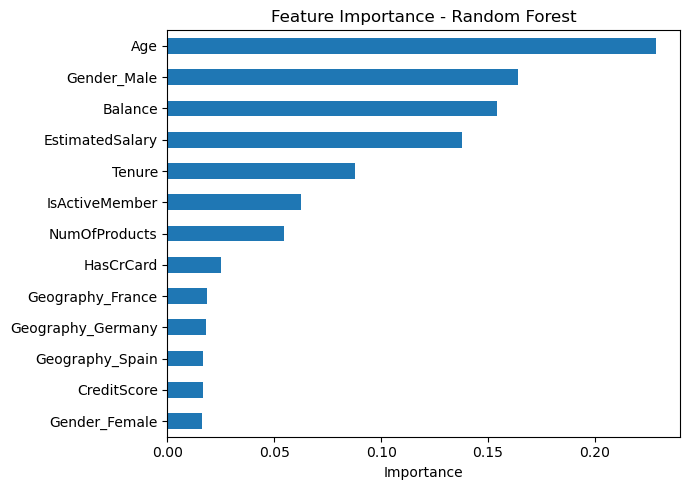

In [50]:
# Feature Importance - Random Forest

feature_names=["CreditScore","Geography_France","Geography_Germany","Geography_Spain","Gender_Female","Gender_Male","Age","Tenure","Balance","NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary"]
importances=classifier.feature_importances_
feature_importance=pd.Series(importances,index=feature_names).sort_values()
feature_importance.plot(kind="barh", figsize=(7,5))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Which customers is the model flagging as churn risks?

This is the actionable output for the business: a list of `CustomerId`s the
bank might want to proactively reach out to.

In [53]:
risky_customers = [int(customer_id) for customer_id, pred in zip(id_test, y_pred_best) if pred == 1]
print(f"{len(risky_customers)} customers flagged as churn risks out of {len(id_test)} in the test set:")
print(risky_customers)

64 customers flagged as churn risks out of 200 in the test set:
[15600859, 15600298, 15600672, 15600306, 15600055, 15600014, 15600031, 15600310, 15600311, 15600788, 15600045, 15600760, 15600001, 15600823, 15600710, 15600790, 15600736, 15600230, 15600819, 15600316, 15600262, 15600272, 15600643, 15600142, 15600202, 15600413, 15600531, 15600412, 15600601, 15600982, 15600501, 15600874, 15600279, 15600367, 15600644, 15600873, 15600636, 15600789, 15600097, 15600523, 15600255, 15600382, 15600489, 15600780, 15600904, 15600939, 15600608, 15600624, 15600101, 15600424, 15600054, 15600034, 15600271, 15600403, 15600457, 15600860, 15600580, 15600688, 15600418, 15600751, 15600767, 15600999, 15600315, 15600204]


## Summary

* I trained 5 different classification models: Logistic Regression, KNN, SVM, Decision Tree, and Random Forest.
* I compared the models using Accuracy, Precision, Recall, and F1-score.
* I used F1-score to choose the best model because the main goal is to correctly identify customers who may leave the bank.
* I also checked the feature importance of the Random Forest model to see which customer features have more effect on churn.
* Finally, I used the best model to identify customers who are predicted to leave the bank.